In [25]:
# 1. Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from itertools import product

PATH = Path(_dh[0]).resolve()  # Set path to parent directory  

In [26]:
 # 11. Load Empirical Data Files
sample_size = [10, 30, 50, 100, 500, 1000]
estimators = ['OLSE', 'LTS', 'Theils', 'Bayesian']

cell = ['Standard', 'Outliers', 'Mixtures', 'Contaminations']
distributions = ['Normal', 'Lognormal', 'Cauchy']

parameter_grid = list(product(cell,distributions))



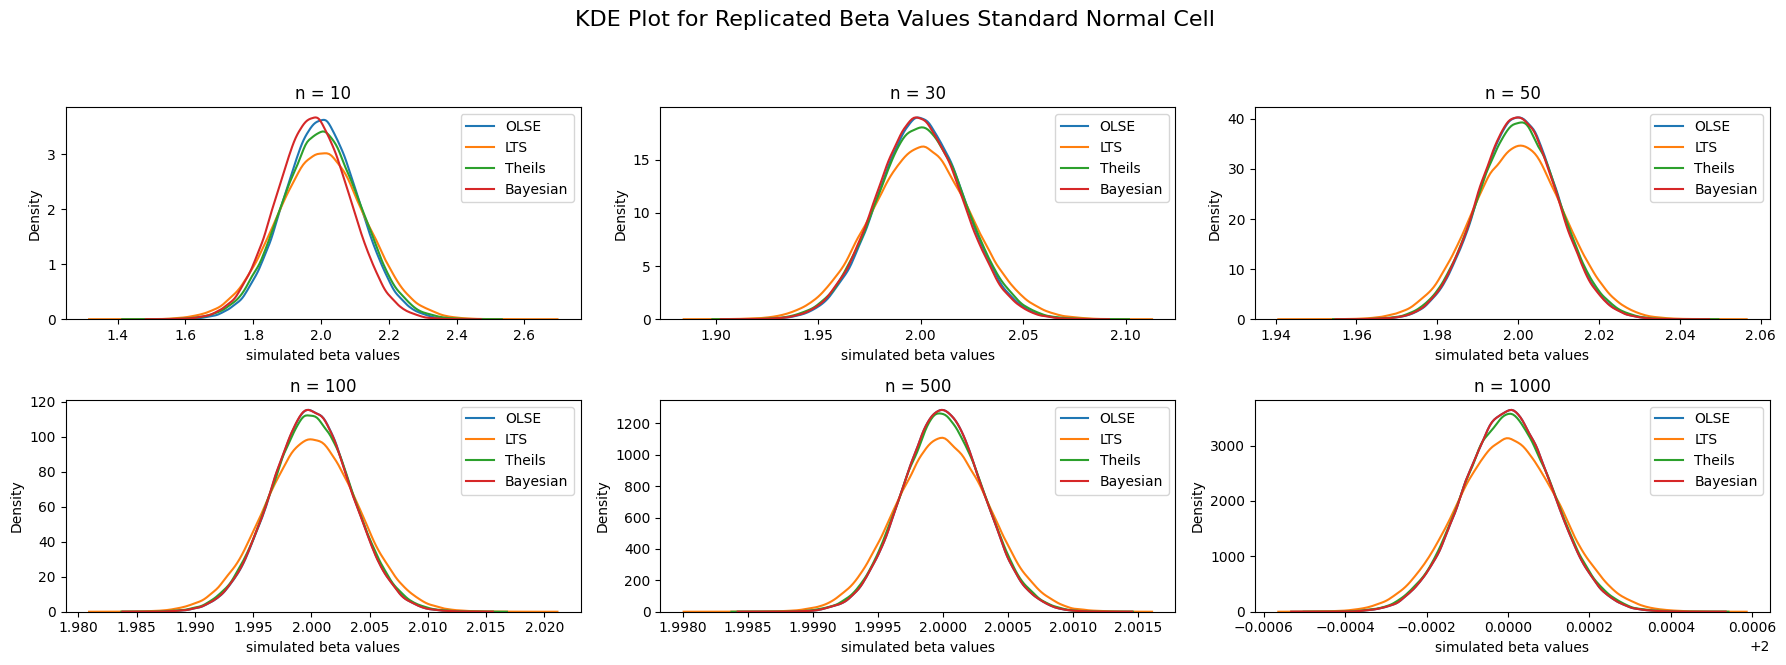

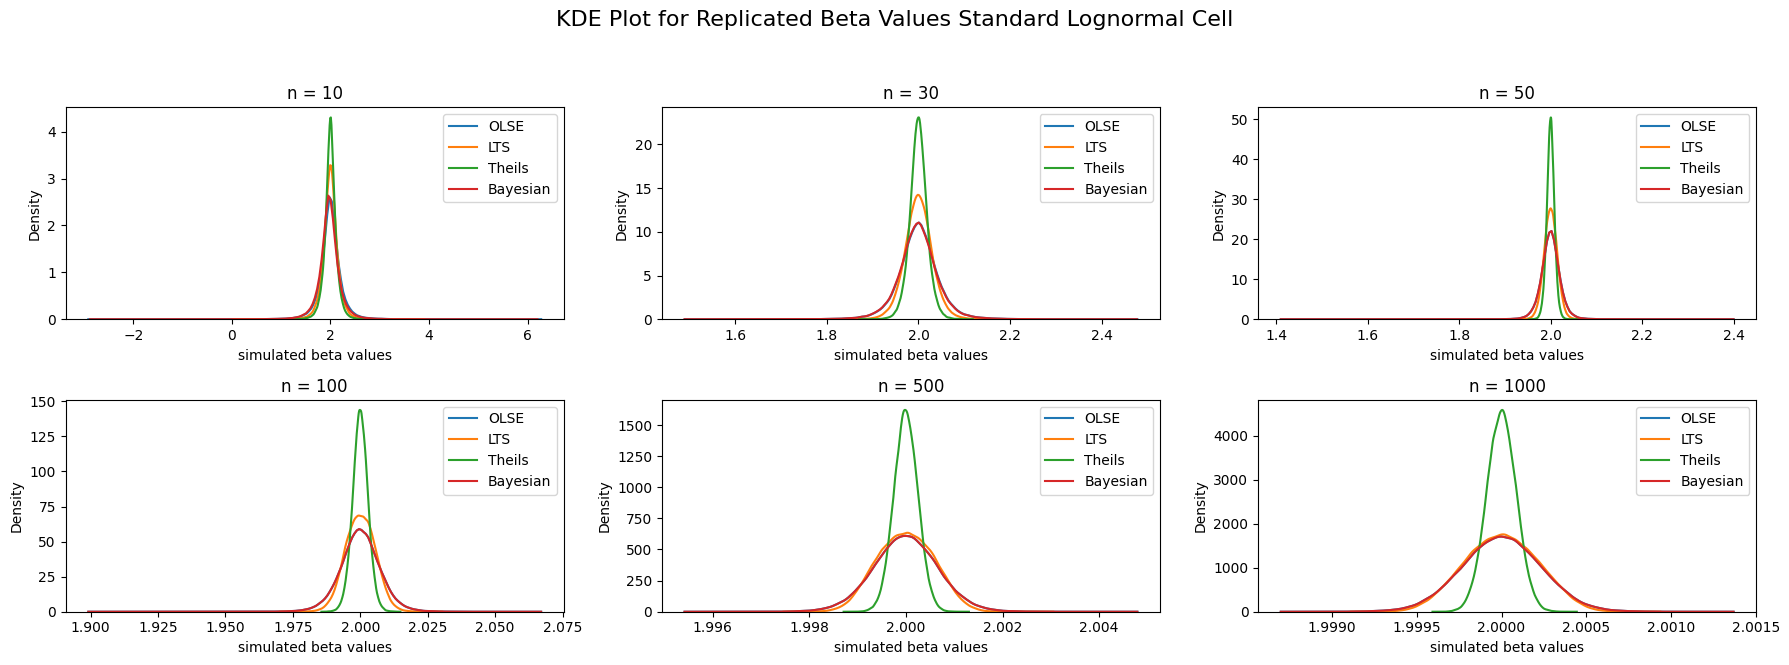

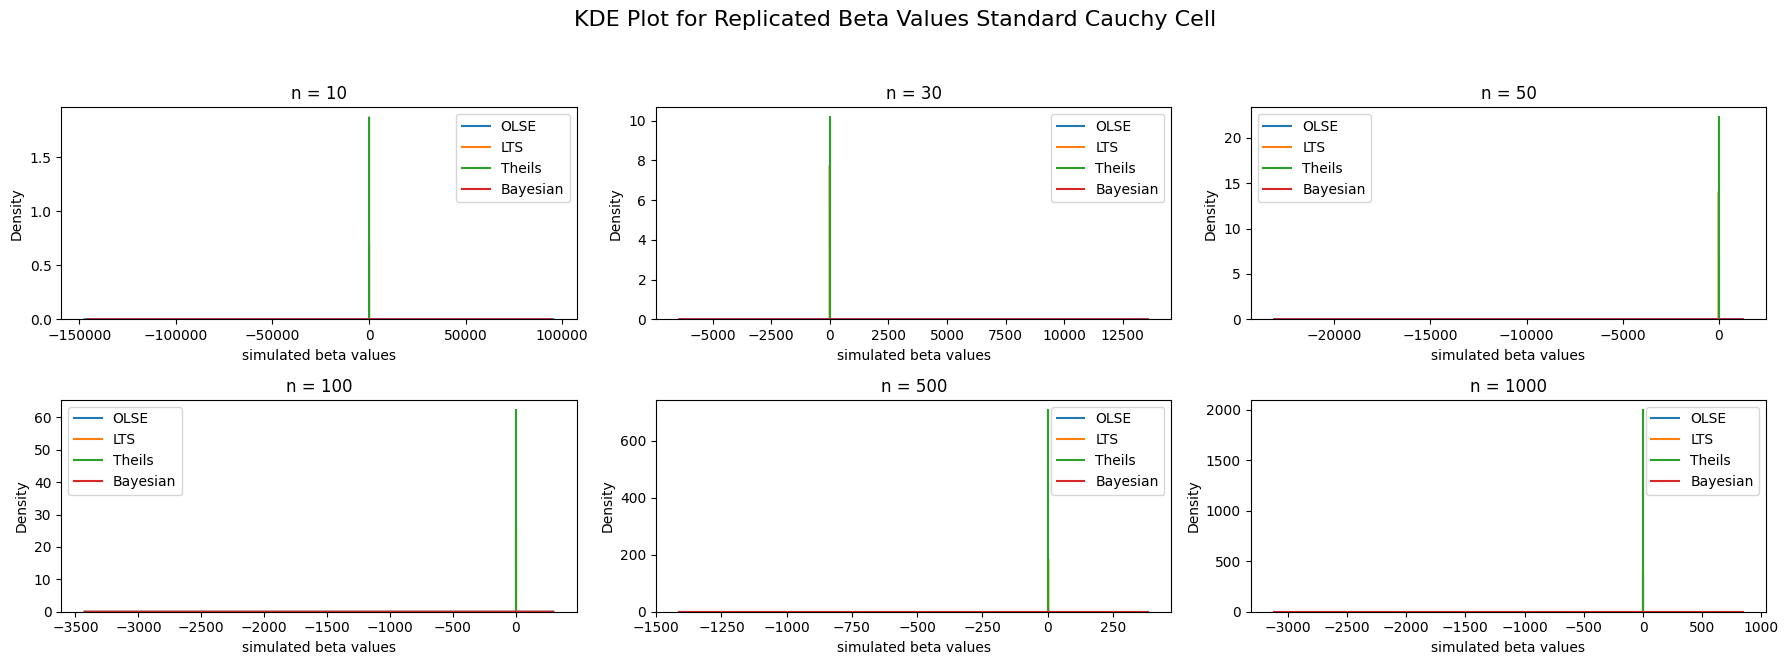

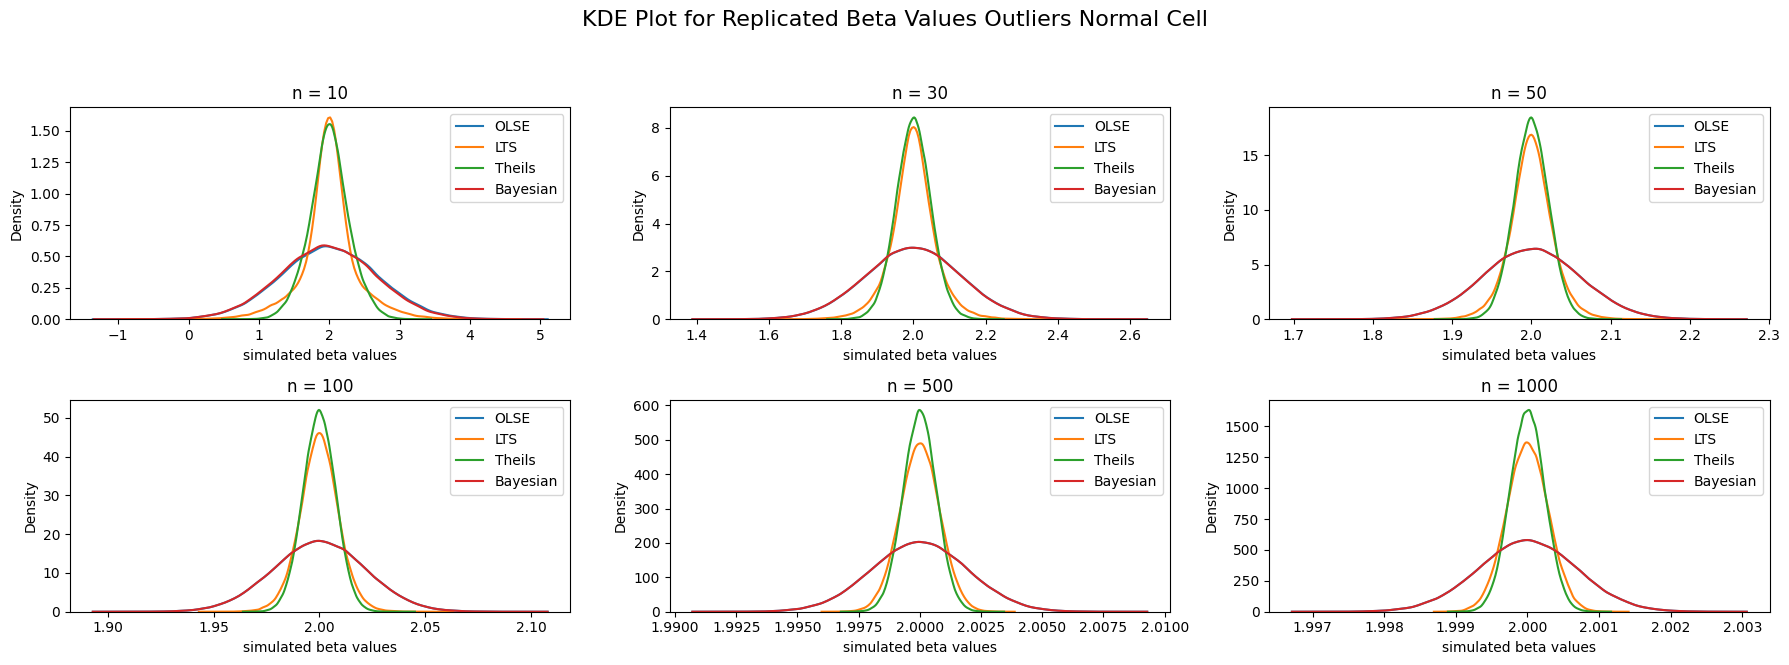

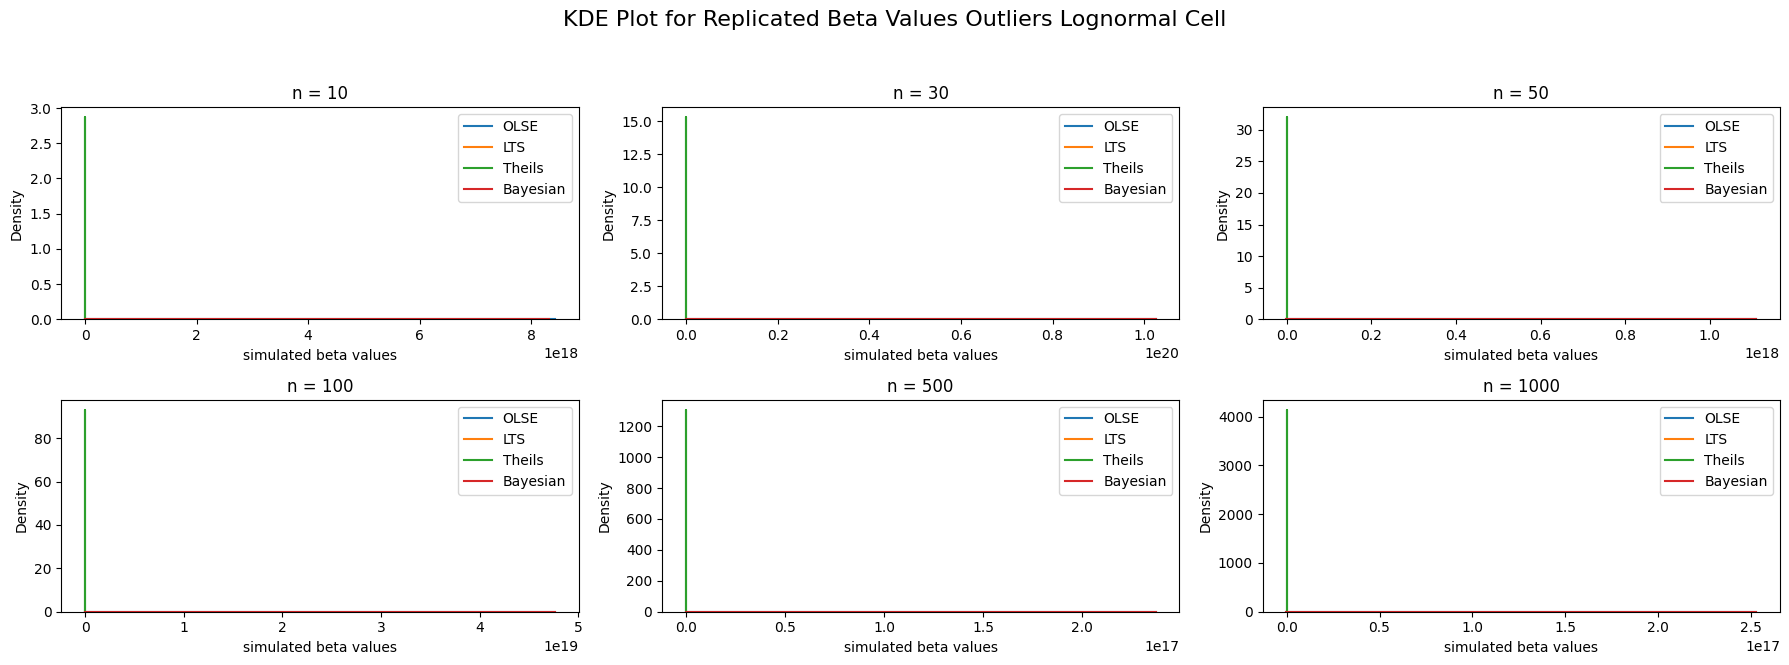

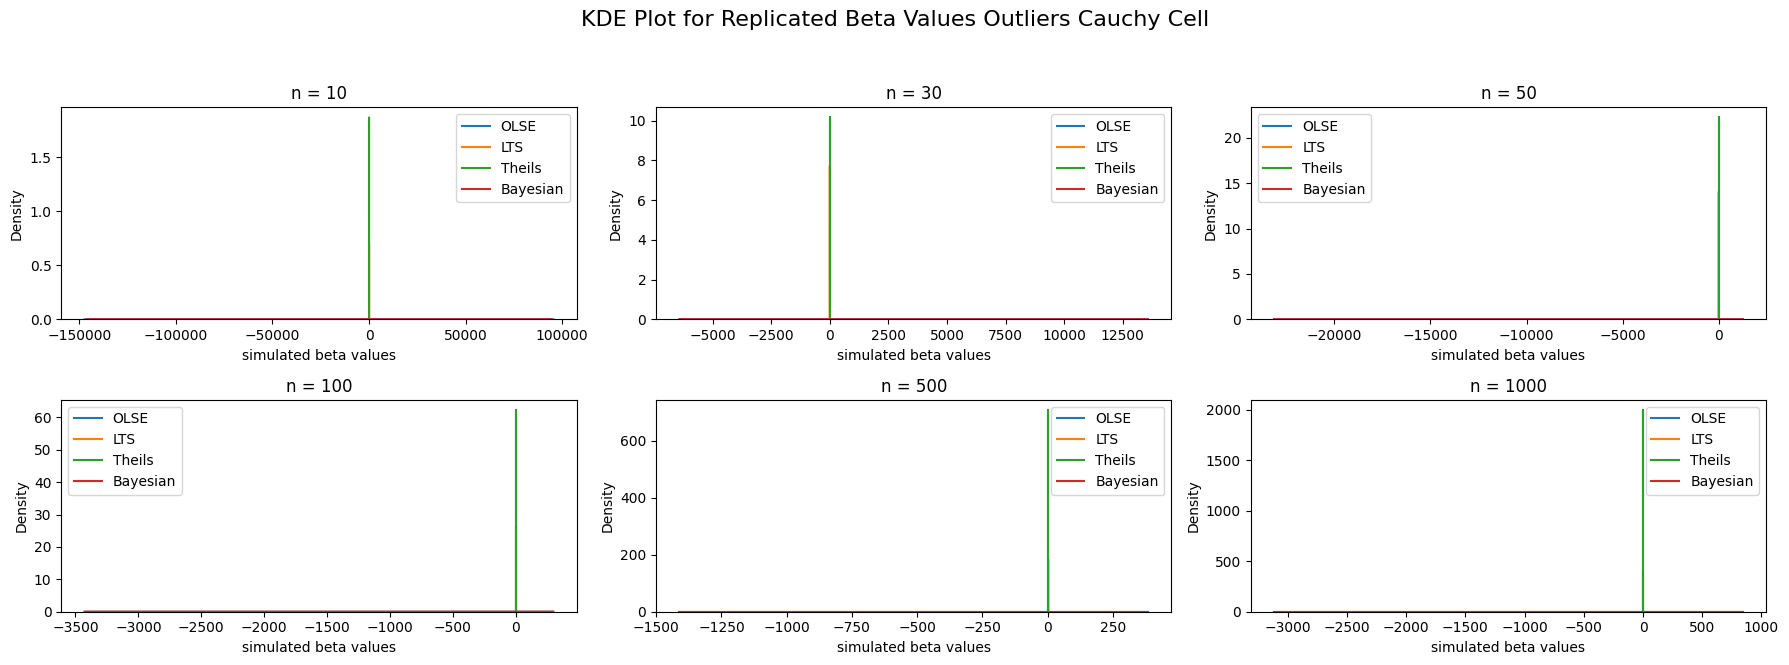

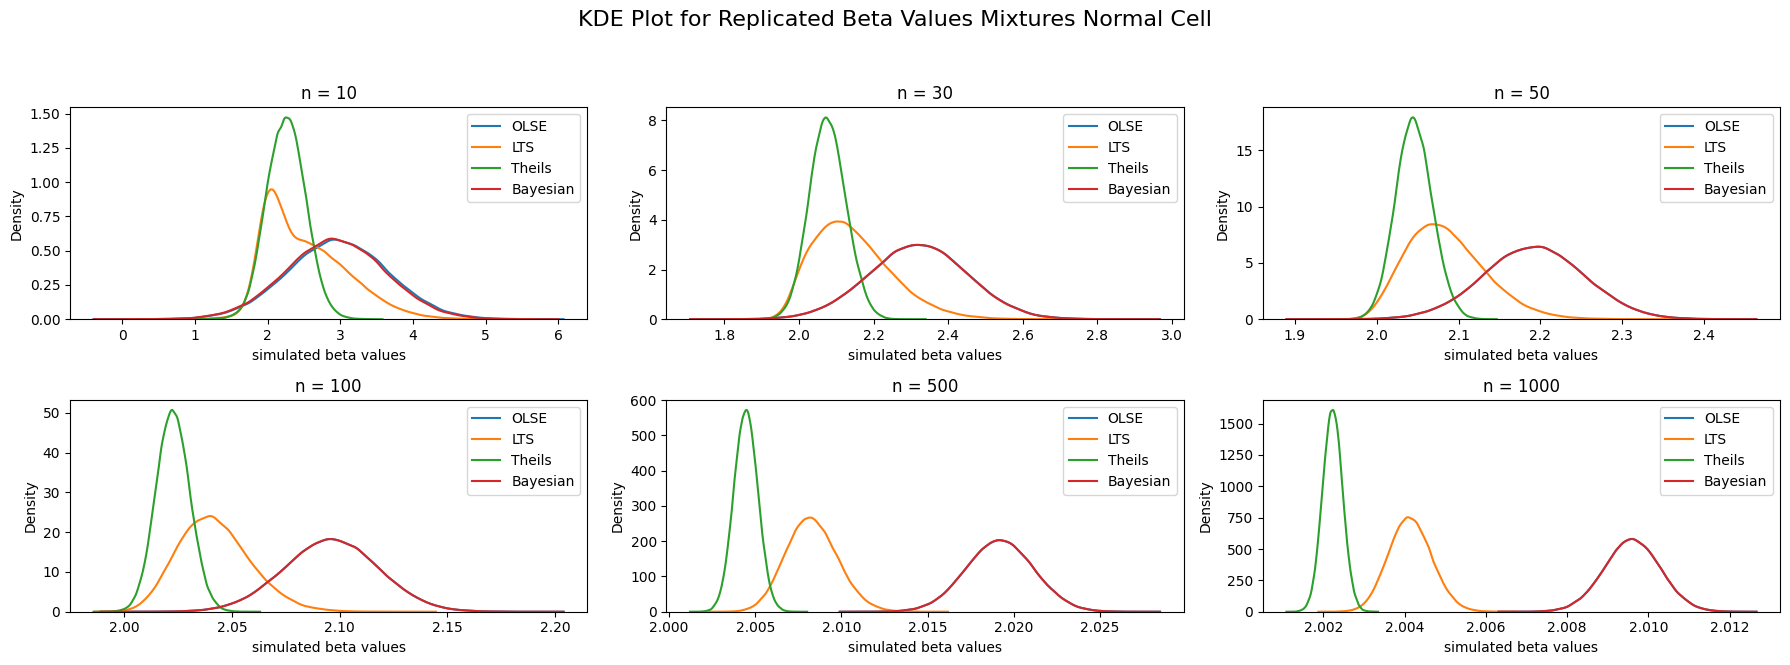

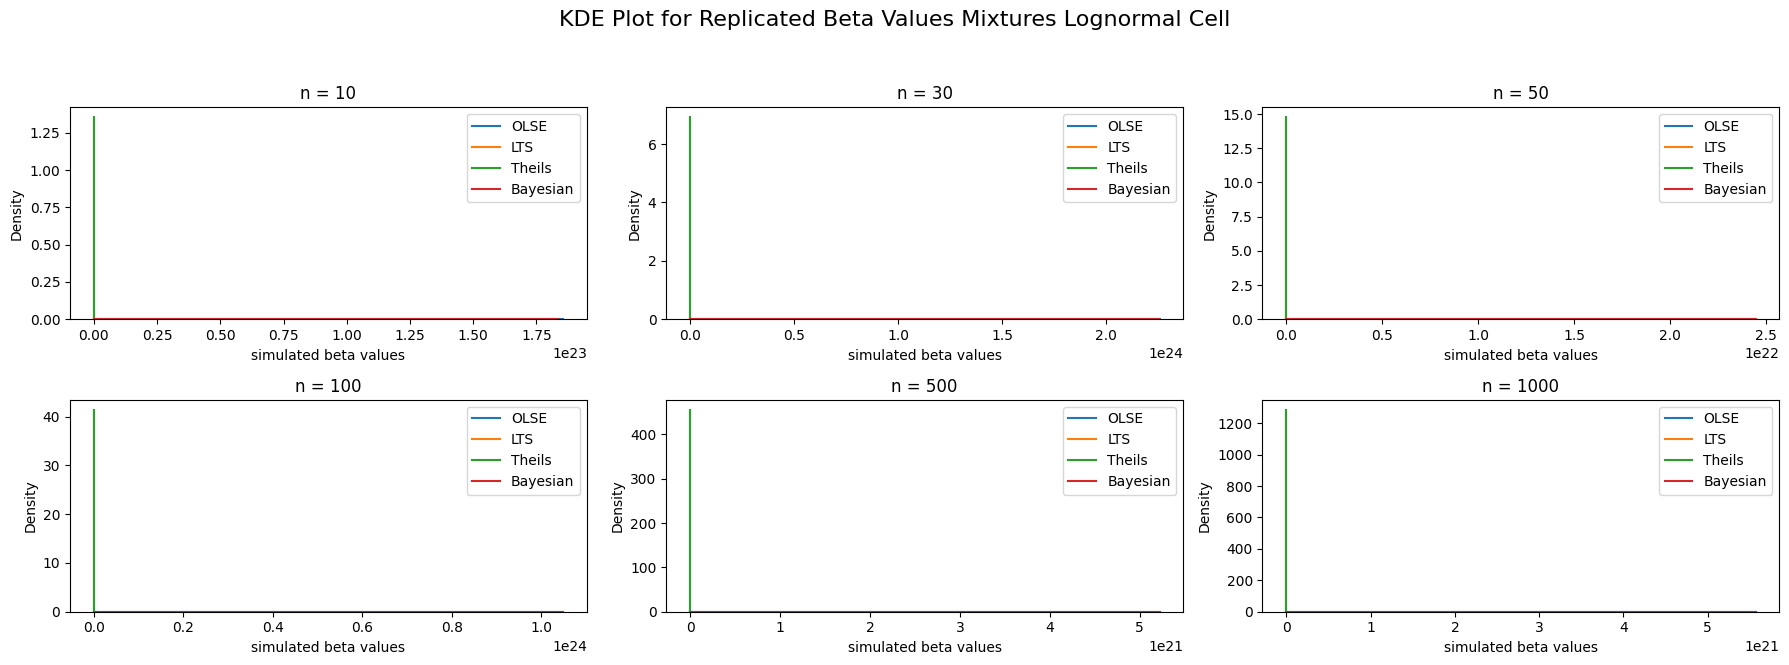

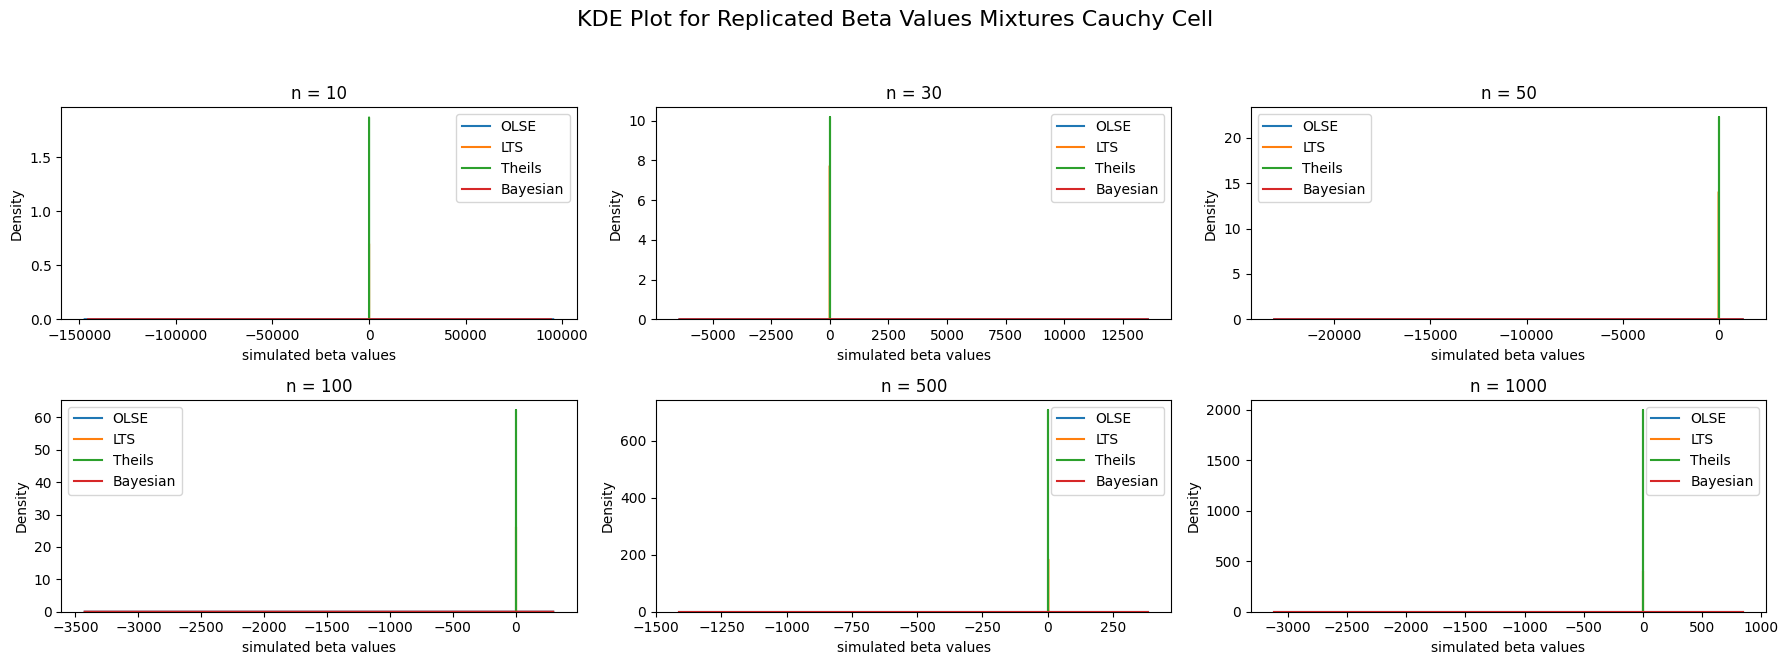

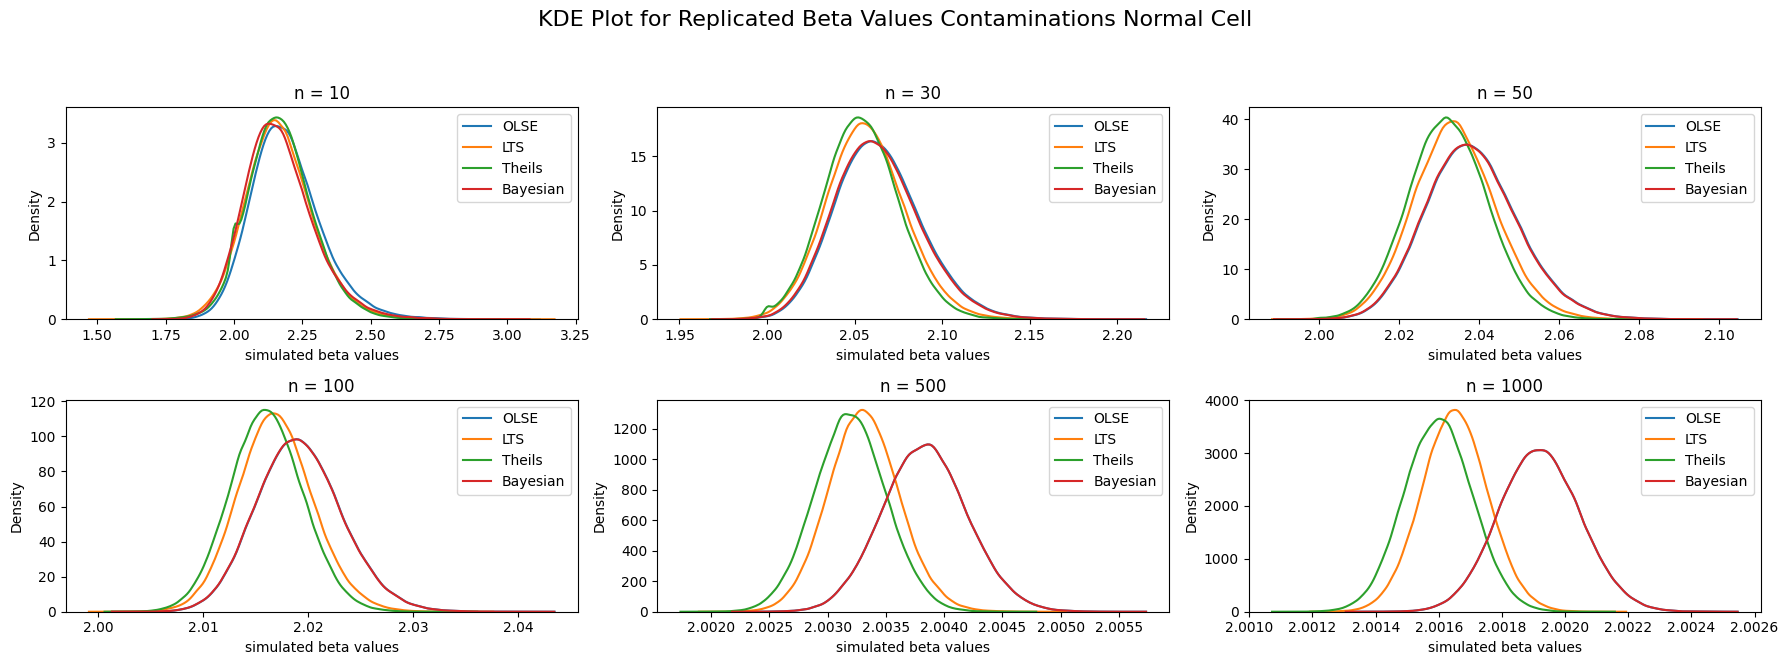

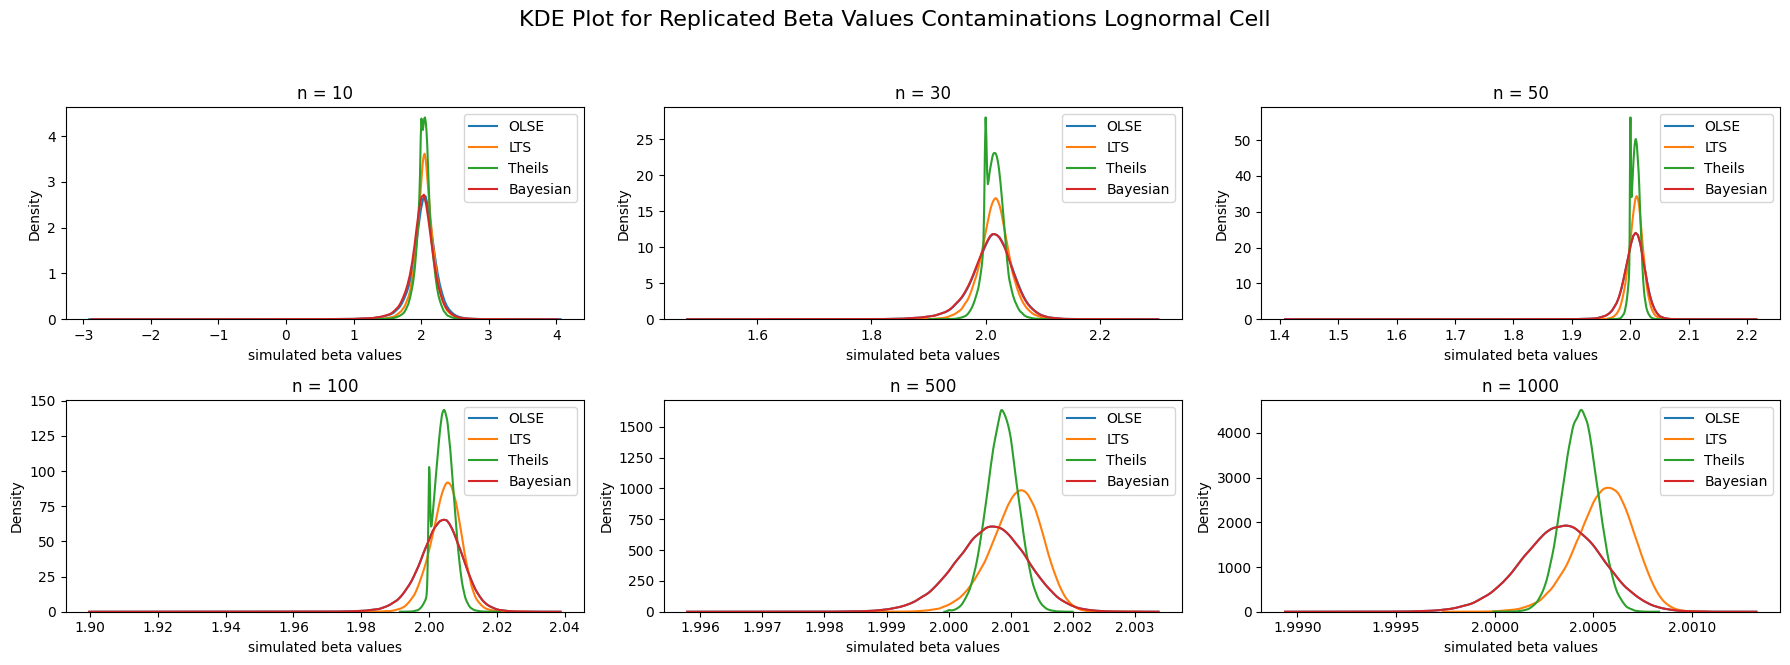

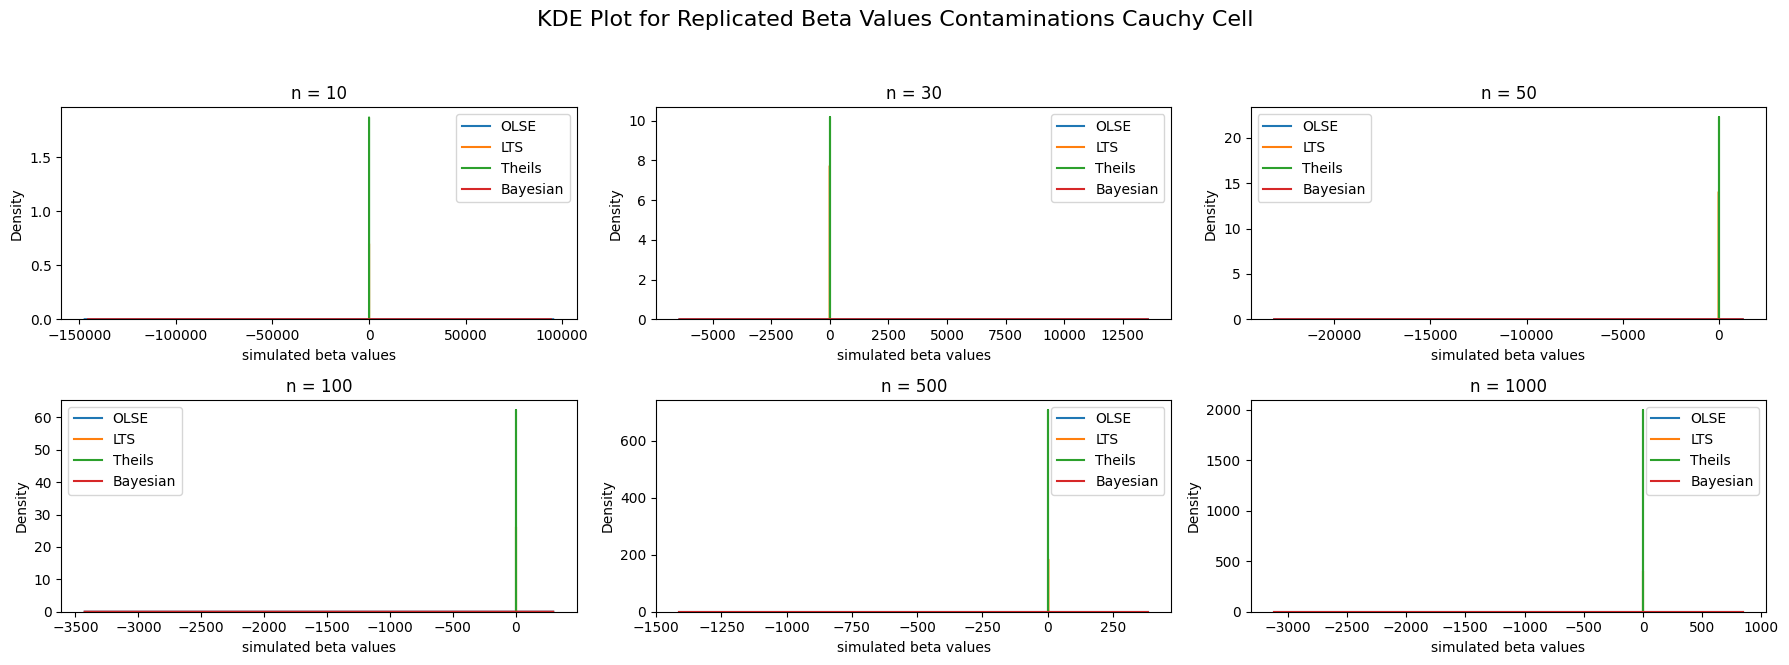

In [27]:
for cell, distr in parameter_grid:

    data_path10 = PATH / f"simulated data {cell} {distr} n = 10.csv"
    data_path30 = PATH / f"simulated data {cell} {distr} n = 30.csv"
    data_path50 = PATH / f"simulated data {cell} {distr} n = 50.csv"
    data_path100 = PATH / f"simulated data {cell} {distr} n = 100.csv"
    data_path500 = PATH / f"simulated data {cell} {distr} n = 500.csv"
    data_path1000 = PATH / f"simulated data {cell} {distr} n = 1000.csv"

    dataset = [data_path10, data_path30, data_path50, data_path100, data_path500, data_path1000]

    fig, ax = plt.subplots(2, 3, figsize=( 6 * 3, 3 * 2))

    for i, data_path in enumerate(dataset):
        data = pd.read_csv(data_path)

        if i <= 2:
            rows = 0 
            cols = i
        else:
            rows = 1
            cols = i - 3

        for est in estimators:
            plot_data = data[data['Method'] == est]['Beta']
            sns.kdeplot(plot_data, ax=ax[rows, cols], label=est)

        ax[rows, cols].set_xlabel('simulated beta values')
        ax[rows, cols].set_ylabel('Density')
        ax[rows, cols].legend()
        ax[rows, cols].set_title(f'n = {sample_size[i]}')

    fig.tight_layout()
    fig.suptitle(f'KDE Plot for Replicated Beta Values {cell} {distr} Cell', fontsize=16, y=1.1)
    fig.savefig(f'{cell} {distr} Cell.png', dpi=300, bbox_inches='tight')
    plt.show()